# State Farm Distracted Driver Detection — MobileNetV3 Transfer Learning (PyTorch)

This notebook trains a **MobileNetV3** classifier on the **State Farm Distracted Driver Detection** dataset using **PyTorch + TorchVision** transfer learning, with a **driver/subject-level split** to reduce leakage.

**Classes (Kaggle):**
- `c0`: safe driving
- `c1`: texting - right
- `c2`: talking on the phone - right
- `c3`: texting - left
- `c4`: talking on the phone - left
- `c5`: operating the radio
- `c6`: drinking
- `c7`: reaching behind
- `c8`: hair and makeup
- `c9`: talking to passenger

> Tip: This notebook is written to be robust for **RTX 50-series (Blackwell / sm_120)** by checking GPU compatibility and using a modern PyTorch build.


## 0) Install pytorch and CUDA GPU support

In [75]:
#Run this in powershell OR if running in notebook, restart kernel after install

%pip install -U pip setuptools wheel

#pytorch, torchvision
#NOTE: the '+cu130' part is important for NVIDIA CUDA 13 gpu compatibility
%pip install torch==2.9.1+cu130 torchvision==0.24.1+cu130 --index-url https://download.pytorch.org/whl/cu130

#If cu130 isn't available for you system use cu128 instead

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.


### Install the rest of the training stack


In [76]:
#other stuff
%pip install numpy==2.4.1 pandas==2.3.3 scikit-learn==1.8.0 pillow==12.1.0 tqdm==4.67.1 matplotlib==3.10.8


Note: you may need to restart the kernel to use updated packages.


## 1) Imports, config

In [77]:
import os
from pathlib import Path
import random
import math
import time
import json

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights


## 2) GPU and CUDA chekcs

- CUDA availability
- device name
- compute capability (sm version)
- torch/torchvision versions


In [78]:
def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        #make a random tensor to test kernel
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected, fall back to CPU.")

cuda_sanity_check()


torch: 2.9.1+cu130
torchvision: 0.24.1+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: -0.014887399971485138


## 3) Dataset (statefarm from kaggle)
https://www.kaggle.com/datasets/rightway11/state-farm-distracted-driver-detection

Expected layout

```
state_farm/
  driver_imgs_list.csv
  imgs/
    train/
      c0/....
      c1/....
      ...
      c9/....
    test/...
```


In [79]:
#dataset folder
DATA_ROOT = Path(r"../Datasets/statefarm")  

CSV_PATH = DATA_ROOT / "driver_imgs_list.csv"
TRAIN_DIR = DATA_ROOT / "imgs_resized_256" / "train"

assert CSV_PATH.exists(), f"Missing {CSV_PATH}"
assert TRAIN_DIR.exists(), f"Missing {TRAIN_DIR}. Expected imgs_resized_256/train/c0..c9"
print("Found:", CSV_PATH)
print("Found:", TRAIN_DIR)


Found: ../Datasets/statefarm/driver_imgs_list.csv
Found: ../Datasets/statefarm/imgs_resized_256/train


## 4) Build a driver/subject level train/val split (prevents leakage)

split by **`subject`** column from `driver_imgs_list.csv`.


In [80]:
df = pd.read_csv(CSV_PATH)
df.head()


,subject,classname,img
0,p012,c0,img_10206.jpg
1,p012,c0,img_27079.jpg
2,p012,c0,img_50749.jpg
3,p012,c0,img_97089.jpg
4,p012,c0,img_37741.jpg


In [81]:
#more checks
required_cols = {"subject", "classname", "img"}
missing = required_cols - set(df.columns)
assert not missing, f"CSV missing columns: {missing}"

df["path"] = df.apply(lambda r: TRAIN_DIR / r["classname"] / r["img"], axis=1)
missing_files = (~df["path"].apply(lambda p: p.exists())).sum()
assert missing_files == 0, f"Some image paths are missing ({missing_files}). Check your folder structure."

classes = sorted(df["classname"].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

print("Classes:", classes)
print("Num images:", len(df))
print("Num subjects:", df["subject"].nunique())


Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Num images: 34924
Num subjects: 20


In [82]:
#keeps all images for a subject either in train or val to prevent leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df["subject"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df))
print("Train subjects:", train_df["subject"].nunique(), "Val subjects:", val_df["subject"].nunique())


Train: 27872 Val: 7052
Train subjects: 16 Val subjects: 4


## 5) Transforms (MobileNetV3 defaults + augmentation)

official ImageNet normalization from the MobileNetV3 weights metadata.


In [ ]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import v2
from torchvision.models import MobileNet_V3_Large_Weights

weights = MobileNet_V3_Large_Weights.DEFAULT

#use official preprocessing pipeline attached the weights
preprocess = weights.transforms()

#get mean and std or else fallback
mean = getattr(preprocess, "mean", None) or weights.meta.get("mean", [0.485, 0.456, 0.406])
std  = getattr(preprocess, "std", None)  or weights.meta.get("std",  [0.229, 0.224, 0.225])

crop_size = getattr(preprocess, "crop_size", (224, 224))
#IMG_SIZE = crop_size[0] if isinstance(crop_size, (tuple, list)) else int(crop_size)

IMG_SIZE = 288

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), 
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print("IMG_SIZE:", IMG_SIZE)
print("mean:", mean, "std:", std)


IMG_SIZE: 320
mean: [0.485, 0.456, 0.406] std: [0.229, 0.224, 0.225]


## 6) Dataset / DataLoaders


In [84]:
class StateFarmCSVDataset(Dataset):
    def __init__(self, frame, class_to_idx, transform=None, cache_images=False):
        self.frame = frame.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.cache_images = cache_images
        self._cache = {} 

    def __len__(self):
        return len(self.frame)

    def _load_image(self, i):
        if self.cache_images and i in self._cache:
            return self._cache[i].copy() 

        img_path = self.frame.loc[i, "path"]
        im = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[i] = im.copy()

        return im

    def __getitem__(self, i):
        row = self.frame.loc[i]
        y = self.class_to_idx[row["classname"]]
        im = self._load_image(i)
        x = self.transform(im) if self.transform else transforms.ToTensor()(im)
        return x, y

train_ds = StateFarmCSVDataset(train_df, class_to_idx, transform=train_tfms, cache_images=False)
val_ds   = StateFarmCSVDataset(val_df, class_to_idx, transform=val_tfms,   cache_images=False)

BATCH_SIZE = 64
NUM_WORKERS = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True, 
    persistent_workers=True,  
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    persistent_workers=True,
)


print("NUM_WORKERS:", NUM_WORKERS)


NUM_WORKERS: 8


In [85]:
import time
t0 = time.time()
xb, yb = next(iter(train_loader))
print("Got batch:", xb.shape, yb.shape, "in", round(time.time()-t0, 2), "sec")


Got batch: torch.Size([64, 3, 320, 320]) torch.Size([64]) in 0.6 sec


## 7) Model: MobileNetV3-Large transfer learning


In [86]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#mobilenetV3 weights
weights = MobileNet_V3_Large_Weights.DEFAULT
model = mobilenet_v3_large(weights=weights)

num_classes = len(classes)

last_channel = model.classifier[-1].in_features
model.classifier[-1] = nn.Sequential(
    nn.Linear(last_channel, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.2), 
    nn.Linear(1280, num_classes)
)
#freeze most of the network, unfreeze last few blocks

#1) Freeze everything first (dont change weights or gradients)
for p in model.parameters():
    p.requires_grad = False

#2) unfreeze last classifier layer
for p in model.classifier.parameters():
    p.requires_grad = True

#3) Unfreeze last N blocks of feature extractor
#helps model adapt higher level features to dataset.
UNFREEZE_LAST_N_BLOCKS = 10  #dont put this too high or else overfit

#convert to list to slice the last N blocks
feature_blocks = list(model.features.children())

#unfreeze last N feature blocks
for block in feature_blocks[-UNFREEZE_LAST_N_BLOCKS:]:
    for p in block.parameters():
        p.requires_grad = True

#move model onto device (GPU or CPu)
model = model.to(device)

#performance tweaks
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

#print out frozen and unfrozen layers
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

print("Unfroze last", UNFREEZE_LAST_N_BLOCKS, "feature blocks + classifier.")


Trainable params: 5,793,402 / 5,854,522 (98.96%)
Unfroze last 10 feature blocks + classifier.


## 8) Training utilities (AMP + metrics + checkpointing)


In [ ]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    epochs: int = 25
    lr: float = 0.0003
    weight_decay: float = 0.01
    label_smoothing: float = 0.1
    grad_clip: float = 1.0

    #early stopping config
    patience: int = 15 #wait 8 epochs without improvement before stopping
    min_delta: float = 0.002   #track actual imrprovement and not random variation

    out_dir: Path = Path("./checkpoints")
    best_name: str = "mobilenetv3_statefarm_best.pt"


cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
print(cfg)


TrainConfig(epochs=25, lr=0.003, weight_decay=0.001, label_smoothing=0.02, grad_clip=1.0, patience=15, min_delta=0.002, out_dir=PosixPath('checkpoints'), best_name='mobilenetv3_statefarm_best.pt')


In [ ]:
#assign importance to underperforming classes
class_weights = torch.tensor([1.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.2]).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

feature_params = []
head_params = []

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if "classifier" in name:
        head_params.append(p)
    else:
        feature_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": feature_params, "lr": cfg.lr * 0.1}, #small LR for backbone
        {"params": head_params, "lr": cfg.lr}, #larger LR for head
    ],
    weight_decay=cfg.weight_decay
)

#3. Cosine Annealing Scheduler 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs,
    eta_min=1e-6
)

def get_lrs(opt):
    return [pg["lr"] for pg in opt.param_groups]

#AMP scaler for performance
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

#GPU augs
mean_tensor = torch.tensor(mean).view(1, 3, 1, 1).to(device)
std_tensor = torch.tensor(std).view(1, 3, 1, 1).to(device)

class GPUAugment(nn.Module):
    def __init__(self):
        super().__init__()
        self.aug = nn.Sequential(
            # ColorJitter: Randomly change brightness, contrast, saturation, hue
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
            # RandomErasing: Randomly black out a rectangle
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
        )

    def forward(self, x):
        # x is [Batch, 3, H, W] in range [0, 1]
        x = self.aug(x)
        # Normalize: (x - mean) / std
        return (x - mean_tensor) / std_tensor

class GPUValidation(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Validation only needs normalization
        return (x - mean_tensor) / std_tensor

gpu_aug = GPUAugment().to(device)
gpu_val = GPUValidation().to(device)

def run_one_epoch(model, loader, train: bool):
    model.train(train)
    all_y = []
    all_p = []
    total_loss = 0.0
    
    if train:
        gpu_aug.train()
    else:
        gpu_val.eval()

    pbar = tqdm(loader, desc="train" if train else "val", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        
        #gpu transforms
        with torch.no_grad():
            if train:
                xb = gpu_aug(xb)
            else:
                xb = gpu_val(xb)

        #mixup logic
        #pply mixup to all batches to force maximum generalization
        use_mixup = train 
        
        if use_mixup:
            #generate mixing ratio (lambda)
            alpha = 0.2 #lower = easier mixes to learn, vice versa
            lam = np.random.beta(alpha, alpha)
            
            index = torch.randperm(xb.size(0)).to(device)
            
            #create mixed image
            mixed_x = lam * xb + (1 - lam) * xb[index]
            
            y_a, y_b = yb, yb[index]
            
            #forward pass
            with torch.set_grad_enabled(train):
                with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                    logits = model(mixed_x)
                    
                    #mix the loss
                    loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

        else:
            #val
            with torch.set_grad_enabled(train):
                with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                    logits = model(xb)
                    loss = criterion(logits, yb)

        #back pass
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            
            if cfg.grad_clip is not None and cfg.grad_clip > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

            scaler.step(optimizer)
            scaler.update()

        total_loss += float(loss.item()) * xb.size(0)

        preds = logits.argmax(dim=1)
        all_y.append(yb.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())
        pbar.set_postfix(loss=float(loss.item()))

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, acc, f1

def save_checkpoint(path: Path, model):
    torch.save(model.state_dict(), path)

    meta = {
        "classes": classes,
        "class_to_idx": class_to_idx,
        "img_size": IMG_SIZE,
        "mean": mean,
        "std": std,
        "torch_version": str(torch.__version__), 
    }
    with open(path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)


best_val_f1 = -1.0
best_epoch = -1
bad_epochs = 0

history = []


## 9) Train


In [ ]:
for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    
    train_loss, train_acc, train_f1 = run_one_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_one_epoch(model, val_loader, train=False)

    #update scheduler once
    scheduler.step()
    
    dt = time.time() - t0
    
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"TL {train_loss:.4f} TA {train_acc:.4f} | "
        f"VL {val_loss:.4f} VA {val_acc:.4f} VF1 {val_f1:.4f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    #save best based on f1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        save_checkpoint(cfg.out_dir / cfg.best_name, model)
        print("  -> Saved Best!")


print("Best epoch:", best_epoch, "Best val f1:", best_val_f1) 


Epoch 01/25 | train loss 0.7084 acc 0.5251 f1 0.5250 | val loss 0.8962 acc 0.7629 f1 0.7578 | 37.7s
saved best (val_f1): checkpoints/mobilenetv3_statefarm_best.pt


Epoch 02/25 | train loss 0.5577 acc 0.5817 f1 0.5813 | val loss 0.8484 acc 0.7595 f1 0.7588 | 36.1s


Epoch 03/25 | train loss 0.5083 acc 0.5408 f1 0.5410 | val loss 1.0523 acc 0.6625 f1 0.6659 | 34.0s


Epoch 04/25 | train loss 0.4897 acc 0.5045 f1 0.5044 | val loss 0.8029 acc 0.7768 f1 0.7512 | 36.8s


Epoch 05/25 | train loss 0.4705 acc 0.5376 f1 0.5377 | val loss 0.8663 acc 0.7604 f1 0.7576 | 36.6s


...

Epoch 20/25 | train loss 0.3984 acc 0.5593 f1 0.5594 | val loss 0.7866 acc 0.7635 f1 0.7644 | 36.4s


Epoch 21/25 | train loss 0.4039 acc 0.5633 f1 0.5631 | val loss 0.7872 acc 0.7869 f1 0.7766 | 36.0s


Epoch 22/25 | train loss 0.3801 acc 0.5469 f1 0.5470 | val loss 0.8548 acc 0.7448 f1 0.7470 | 36.4s


LR reduced from [0.00015000000000000001, 0.0015]  to [7.500000000000001e-05, 0.00075]
Epoch 23/25 | train loss 0.3655 acc 0.5733 f1 0.5733 | val loss 0.8406 acc 0.7635 f1 0.7648 | 36.3s


Epoch 24/25 | train loss 0.3823 acc 0.5371 f1 0.5373 | val loss 0.8500 acc 0.7345 f1 0.7333 | 34.5s
early stopping (no val_f1 improvement for 15 epochs)
Best epoch: 9 Best val f1: 0.8208205095825735


## 10) Print training results


In [90]:

hist = pd.DataFrame(history)
hist


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,seconds,lr
0,1,0.708399,0.525115,0.525009,0.896215,0.762904,0.757794,37.698729,0.000300
1,2,0.557724,0.581659,0.581272,0.848372,0.759501,0.758763,36.065692,0.000300
2,3,0.508342,0.540794,0.540989,1.052290,0.662507,0.665909,33.968376,0.000300
3,4,0.489739,0.504485,0.504438,0.802868,0.776801,0.751207,36.832659,0.000300
4,5,0.470469,0.537565,0.537671,0.866306,0.760352,0.757584,36.572834,0.000300
5,6,0.469680,0.559773,0.559323,0.708362,0.829552,0.799373,36.410776,0.000300
6,7,0.441635,0.551270,0.551466,0.936890,0.713840,0.721076,36.698251,0.000300
7,8,0.492325,0.544776,0.544940,0.819926,0.776234,0.782807,33.784469,0.000300
8,9,0.446320,0.550481,0.550281,0.656669,0.826432,0.820821,36.086415,0.000300
9,10,0.463163,0.546714,0.546296,0.841955,0.738514,0.743544,36.436082,0.000300


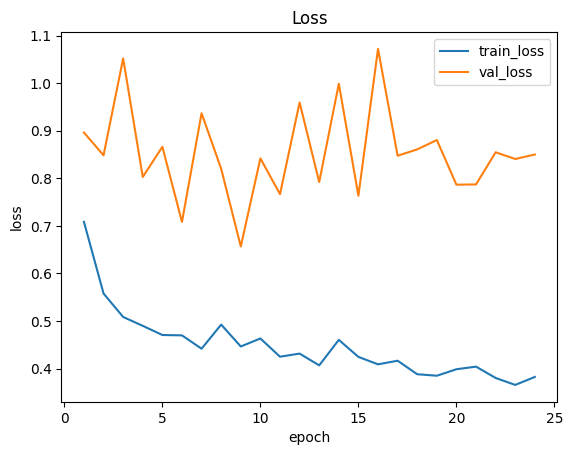

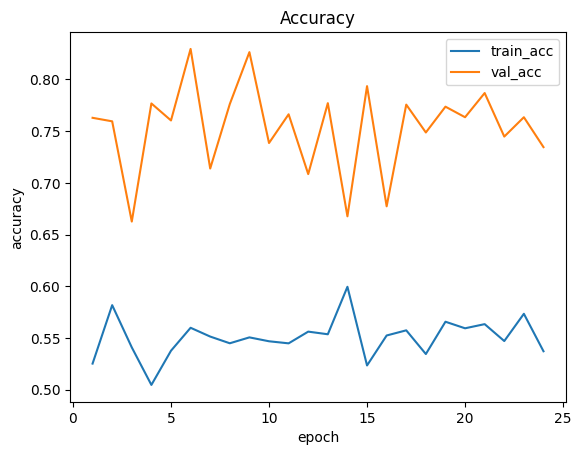

In [91]:
plt.figure()
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.show()


## 11) Detailed validation report


In [92]:
#load best checkpoint 
ckpt_path = cfg.out_dir / cfg.best_name

#1) weights
state_dict = torch.load(ckpt_path, map_location=device, weights_only=False)

#2) metadata
meta_path = ckpt_path.with_suffix(".json")
with open(meta_path, "r") as f:
    meta = json.load(f)

classes_ckpt = meta["classes"]
class_to_idx_ckpt = meta["class_to_idx"]

#3) rebuild model
best_model = mobilenet_v3_large(weights=weights)
best_model.classifier[-1] = nn.Linear(best_model.classifier[-1].in_features, len(classes_ckpt))

#4) weights
best_model = mobilenet_v3_large(weights=weights)

last_channel = best_model.classifier[-1].in_features
best_model.classifier[-1] = nn.Sequential(
    nn.Linear(last_channel, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.5),
    nn.Linear(1280, len(classes_ckpt))
)

best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

#5) evaluate
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="val eval"):
        xb = xb.to(device, non_blocking=True)
        logits = best_model(xb)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=classes_ckpt))


val eval: 100%|██████████| 111/111 [00:06<00:00, 16.23it/s]

Accuracy: 0.6199659671015315
Macro F1: 0.6273019298681471

Classification report:

              precision    recall  f1-score   support

          c0       0.30      0.99      0.46       746
          c1       1.00      0.22      0.36       720
          c2       1.00      0.54      0.70       730
          c3       1.00      0.90      0.95       724
          c4       0.95      0.59      0.73       764
          c5       0.65      0.78      0.71       758
          c6       0.93      0.74      0.82       718
          c7       0.99      0.87      0.92       626
          c8       0.23      0.23      0.23       690
          c9       0.77      0.25      0.38       576

    accuracy                           0.62      7052
   macro avg       0.78      0.61      0.63      7052
weighted avg       0.78      0.62      0.63      7052



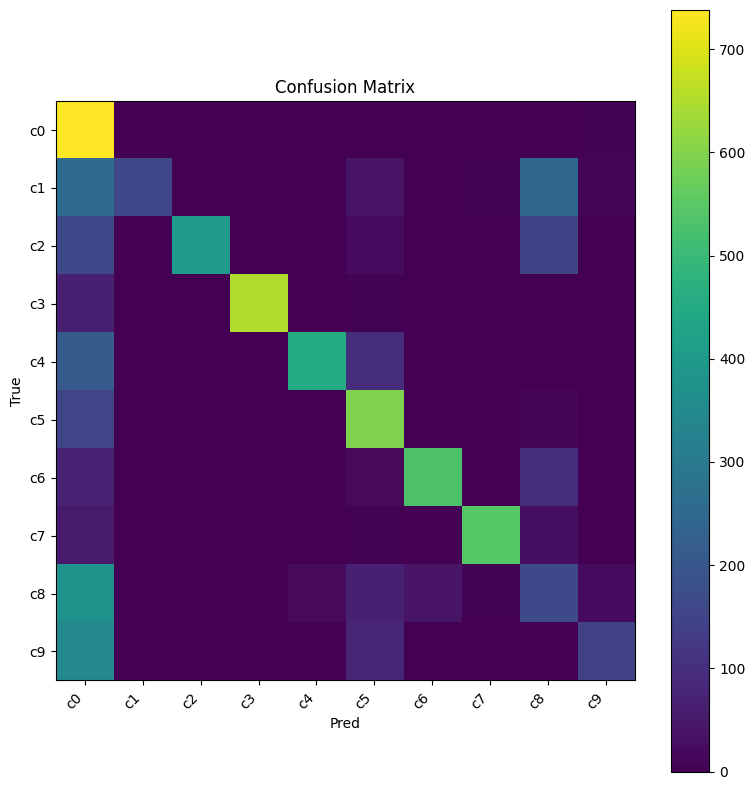

In [93]:
#confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 12) Quick inference on a few images


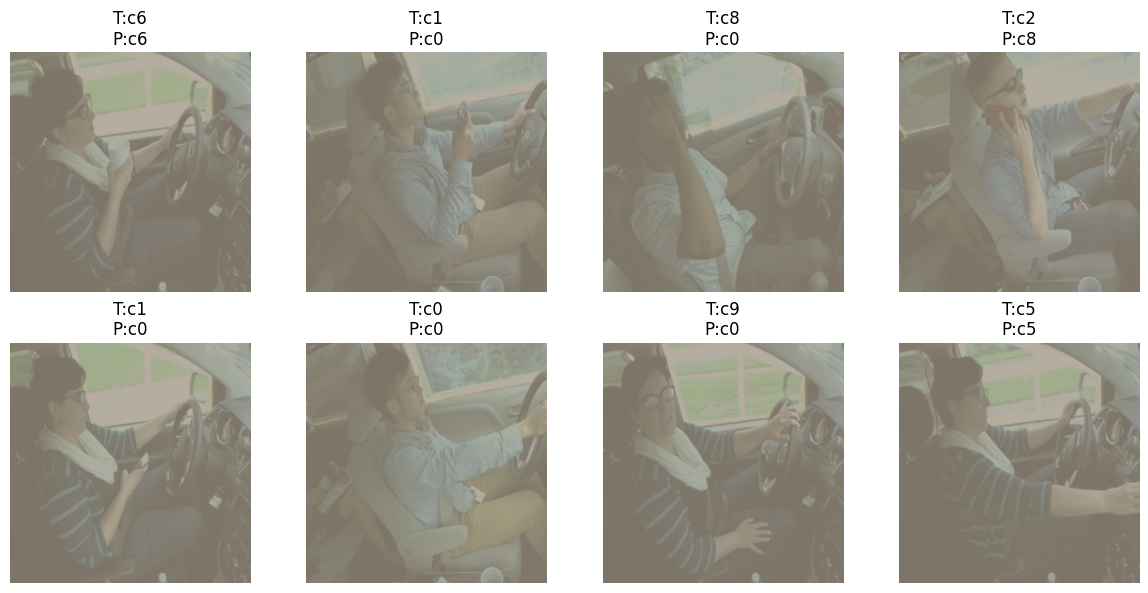

In [94]:
#test inference on some images
def denorm(x, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return (x * std) + mean

best_model.eval()
samples = [val_ds[i] for i in np.random.choice(len(val_ds), size=8, replace=False)]
xb = torch.stack([s[0] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(len(samples)):
    ax = plt.subplot(2, 4, i+1)
    img = denorm(samples[i][0].cpu(), mean, std).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")
    ax.set_title(f"T:{idx_to_class[yb[i]]}\nP:{idx_to_class[pred[i]]}")
plt.tight_layout()
plt.show()


## 13) Export (optional): TorchScript

Useful if you want to deploy the model later (e.g., to a desktop app). For mobile/on-device, you might prefer ONNX or ExecuTorch.


In [95]:
EXPORT = False

if EXPORT:
    best_model.eval()
    example = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    traced = torch.jit.trace(best_model, example)
    out_path = cfg.out_dir / "mobilenetv3_statefarm_traced.pt"
    traced.save(out_path)
    print("Saved:", out_path)


## Notes / common issues

- If you see: **“CUDA capability sm_120 is not compatible”**, you installed a PyTorch build that doesn't include Blackwell kernels. Reinstall Torch from **cu128** or **cu130**.
- If `torch.cuda.is_available()` is `False` on Windows, verify:
  - NVIDIA driver is installed and `nvidia-smi` works
  - your venv doesn't accidentally have CPU-only `torch` from PyPI
